# 01 - Exploratory Data Analysis

**Goal:** Understand the dataset *before* training. 

By the end of this notebook we should know:

1. How many examples are in train and test?
2. What is the class balance? (Decision whether to stratify the split)
3. What does the text look like? (Length distribution)
4. How sparse is the TF-IDF feature matrix? How many features?
5. What is the **intrinsic dimensionality** of the feature space. i.e. how many PCA components do we actually need? (Scree plot with elbow detection, instead of guessing 2000/1000/500/100.)
6. Given all of the above, **what train/validation split makes sense?** 

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from src import paths, data, evaluation
from src.paths import FIGURES
from src.plotting import save_fig
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + confirm schema

Confirm the feature-column names and record the schema. Expected: 20,000 rows, columns
`id`, `label`, plus 5000 TF-IDF feature columns named `'0001'` through `'5000'`
(zero-padded strings). `id` is not numeric, so it must be loaded as `str`.

In [2]:
# Load the raw features file directly first, to inspect the schema before going through
# the src.data loader.
df = pd.read_csv(paths.TRAIN_FEATURES_CSV, dtype={"id": str})
print("shape:", df.shape)
print("first 5 columns:", df.columns[:5].tolist())
print("last 3 columns:", df.columns[-3:].tolist())
print("id dtype:", df["id"].dtype, "| sample id:", df["id"].iloc[0])

feature_cols = [c for c in df.columns if c not in ("id", "label")]
assert len(feature_cols) == 5000
assert feature_cols[0] == "0001" and feature_cols[-1] == "5000"
print(f"\nConfirmed: {len(feature_cols)} feature columns, '0001'..'5000', zero-padded strings.")

# Reuse the shared loader for everything downstream (same schema, sanity-checked above).
X, y, ids = data.load_train_features()
print("\nX:", X.shape, X.dtype, "| y:", y.shape, y.dtype, "| ids:", ids.shape, ids.dtype)

shape: (20000, 5002)
first 5 columns: ['id', 'label', '0001', '0002', '0003']
last 3 columns: ['4998', '4999', '5000']
id dtype: str | sample id: 71ec6000-1f20-4850-a8f7-140bc6ad640d

Confirmed: 5000 feature columns, '0001'..'5000', zero-padded strings.



X: (20000, 5000) float64 | y: (20000,) int64 | ids: (20000,) object


## 2. Class balance

This section determines:
- **Whether to stratify the split.** If 50/50, optional. If skewed, mandatory.
- **What baseline F1 to beat.** Always-predict-majority is the floor.
- **Whether to use `class_weight='balanced'`** in models that support it.

In [3]:
counts = pd.Series(y).value_counts().sort_index()
props = pd.Series(y).value_counts(normalize=True).sort_index()
print("counts:\n", counts.rename({0: "Human", 1: "Machine"}))
print("\nproportions:\n", props.rename({0: "Human", 1: "Machine"}).round(4))

fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(["Human (0)", "Machine (1)"], [props[0], props[1]], color=["#4C72B0", "#DD8452"])
ax.set_xlabel("Proportion of training set")
ax.set_title("Class balance - train_features.csv")
for i, v in enumerate([props[0], props[1]]):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
save_fig(fig, "class_balance.png")

# Reference point for why accuracy would be misleading on this imbalance.
majority_f1 = f1_score(y, np.ones_like(y), average="macro")
print(f"\nMajority-class (all-machine) accuracy: {props[1]:.1%} | Macro F1: {majority_f1:.3f}")
print("Conclusion: skewed, not ~50/50 -> stratification is REQUIRED for every split and CV fold.")

counts:
 Human       7496
Machine    12504
Name: count, dtype: int64

proportions:
 Human      0.3748
Machine    0.6252
Name: proportion, dtype: float64

Majority-class (all-machine) accuracy: 62.5% | Macro F1: 0.385
Conclusion: skewed, not ~50/50 -> stratification is REQUIRED for every split and CV fold.


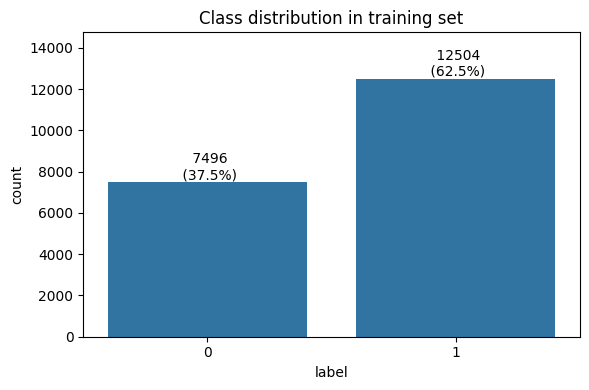

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.set_xlabel("label")
ax.set_ylabel("count")
ax.set_title("Class distribution in training set")
ax.set_ylim(0, counts.max() * 1.18)
for i, v in enumerate(counts.values):
    ax.text(i, v, f" {v}\n ({props.iloc[i]:.1%})", va="bottom", ha="center")
plt.tight_layout()
plt.savefig(FIGURES / "class_balance.png", dpi=120)
plt.show()

## 3. Text length distribution

Raw text lengths (`train.csv`) by class: character count and word count. This is
exploratory. Tasks 1-3 model on the supplied TF-IDF matrix, not raw text, but a length
feature is a documented Task 3 addition if it turns out to separate the
classes.

label                      0             1
char_len count   7496.000000  12504.000000
         mean    1529.446905   1445.123321
         std     1837.783297   1120.622023
         min       27.000000     29.000000
         25%      438.750000    560.000000
         50%     1065.000000   1198.000000
         75%     1762.250000   2029.250000
         max    17436.000000   8597.000000
word_len count   7496.000000  12504.000000
         mean     261.463581    237.554303
         std      307.213141    186.728208
         min        6.000000      6.000000
         25%       81.000000     96.000000
         50%      176.000000    195.000000
         75%      304.000000    329.000000
         max     2950.000000   1528.000000


C:\Users\Cliffton\AppData\Local\Temp\ipykernel_170688\1688645242.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(["Human", "Machine"])
C:\Users\Cliffton\AppData\Local\Temp\ipykernel_170688\1688645242.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Human", "Machine"])


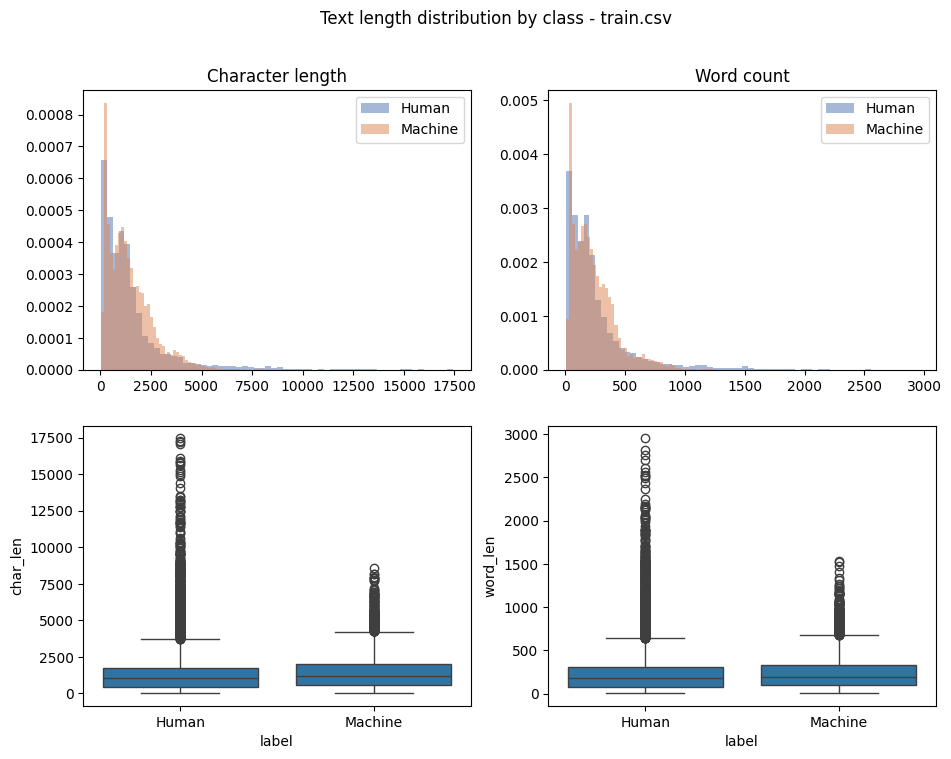


train word_len - mean 246.5, median 187.0
test  word_len - mean 283.9, median 275.0


In [5]:
text_df = pd.read_csv(paths.TRAIN_CSV, dtype={"id": str})
text_df["char_len"] = text_df["text"].str.len()
text_df["word_len"] = text_df["text"].str.split().str.len()

summary = text_df.groupby("label")[["char_len", "word_len"]].describe().T
print(summary)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for label, name, color in [(0, "Human", "#4C72B0"), (1, "Machine", "#DD8452")]:
    subset = text_df[text_df["label"] == label]
    axes[0, 0].hist(subset["char_len"], bins=60, alpha=0.5, label=name, color=color, density=True)
    axes[0, 1].hist(subset["word_len"], bins=60, alpha=0.5, label=name, color=color, density=True)
axes[0, 0].set_title("Character length"); axes[0, 0].legend()
axes[0, 1].set_title("Word count"); axes[0, 1].legend()
sns.boxplot(data=text_df, x="label", y="char_len", ax=axes[1, 0])
sns.boxplot(data=text_df, x="label", y="word_len", ax=axes[1, 1])
axes[1, 0].set_xticklabels(["Human", "Machine"])
axes[1, 1].set_xticklabels(["Human", "Machine"])
fig.suptitle("Text length distribution by class - train.csv")
plt.show()
save_fig(fig, "text_length_distribution.png")

# Eyeball train->test shift while we're here (brief warns of one; test.csv has no labels).
test_text_df = pd.read_csv(paths.TEST_CSV, dtype={"id": str})
test_text_df["word_len"] = test_text_df["text"].str.split().str.len()
print("\ntrain word_len - mean {:.1f}, median {:.1f}".format(
    text_df["word_len"].mean(), text_df["word_len"].median()))
print("test  word_len - mean {:.1f}, median {:.1f}".format(
    test_text_df["word_len"].mean(), test_text_df["word_len"].median()))

## 4. Feature sparsity & statistics

Section 4 investigates two things:

- **Sparsity.** TF-IDF matrices are nearly all zeros. Knowing the exact sparsity tells us whether models like Multinomial Naive Bayes (which suits sparse counts) are well-suited.
- **Per-row non-zero count.** Roughly correlates with how many distinct vocabulary items appear per text. Acts as a sanity check against text length.

In [6]:
nnz_per_row = (X != 0).sum(axis=1)
nnz_per_col = (X != 0).sum(axis=0)
overall_zero_frac = 1 - (X != 0).sum() / X.size

print(f"Overall zero fraction: {overall_zero_frac:.4f}")
print(f"Nonzeros per row  - mean {nnz_per_row.mean():.1f}, median {np.median(nnz_per_row):.1f}, "
      f"min {nnz_per_row.min()}, max {nnz_per_row.max()}")
print(f"Nonzeros per feat - mean {nnz_per_col.mean():.1f}, median {np.median(nnz_per_col):.1f}")

all_zero_features = int((nnz_per_col == 0).sum())
print(f"All-zero features: {all_zero_features}")

feat_var = X.var(axis=0)
near_constant = int((feat_var < 1e-10).sum())
print(f"Near-constant features (var < 1e-10): {near_constant}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nnz_per_row, bins=60, color="#4C72B0")
ax.set_xlabel("Nonzero features per document")
ax.set_ylabel("Count")
ax.set_title(f"Row sparsity - matrix is {overall_zero_frac:.1%} zero overall")
save_fig(fig, "feature_sparsity.png")

Overall zero fraction: 0.9864
Nonzeros per row  - mean 67.8, median 58.0, min 0, max 573
Nonzeros per feat - mean 271.4, median 132.0
All-zero features: 0


Near-constant features (var < 1e-10): 0


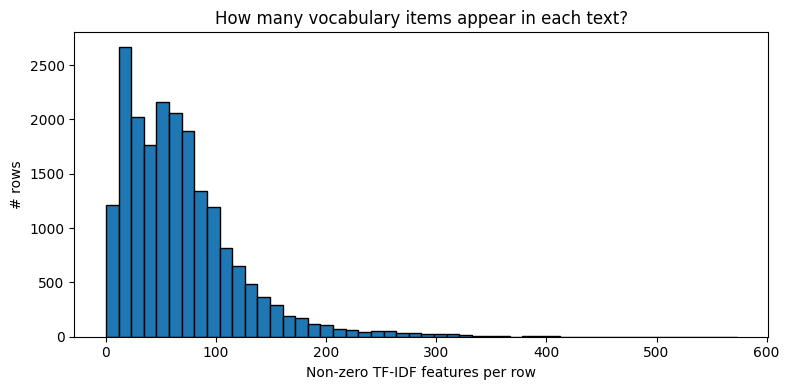

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nnz_per_row, bins=50, edgecolor="black")
ax.set_xlabel("Non-zero TF-IDF features per row")
ax.set_ylabel("# rows")
ax.set_title("How many vocabulary items appear in each text?")
plt.tight_layout()
plt.savefig(FIGURES / "tfidf_nonzero_per_row.png", dpi=120)
plt.show()

## 5. TF-IDF feature-matrix inspection

Beyond simple sparsity, inspect the values themselves: range validity, document-frequency
distribution, and which features carry the most class signal. Feature indices are the only
handle available (the underlying vocabulary is anonymized to `'0001'` through `'5000'`),
but the ranking still tells us which columns to watch in later error analysis.

In [8]:
nonzero_vals = X[X != 0]
print(f"Nonzero value range: min {nonzero_vals.min():.4f}, max {nonzero_vals.max():.4f}, "
      f"mean {nonzero_vals.mean():.4f}")
assert nonzero_vals.min() >= 0, "TF-IDF values should be non-negative"

row_norms = np.linalg.norm(X, axis=1)
print(f"Per-row L2 norm - mean {row_norms.mean():.3f}, std {row_norms.std():.3f}, "
      f"min {row_norms.min():.3f}, max {row_norms.max():.3f}")

# Document frequency per feature (how many docs each feature appears in).
doc_freq = (X != 0).sum(axis=0)
top_common = np.argsort(doc_freq)[::-1][:10]
top_rare = np.argsort(doc_freq)[:10]
print("Most common feature indices (highest doc frequency):", top_common.tolist())
print("Rarest feature indices (lowest doc frequency):", top_rare.tolist())

# Discriminative power: |mean_machine - mean_human| per feature.
mean_machine = X[y == 1].mean(axis=0)
mean_human = X[y == 0].mean(axis=0)
diff = np.abs(mean_machine - mean_human)
top_discriminative = np.argsort(diff)[::-1][:20]

disc_table = pd.DataFrame({
    "feature_idx": [feature_cols[i] for i in top_discriminative],
    "mean_machine": mean_machine[top_discriminative],
    "mean_human": mean_human[top_discriminative],
    "abs_diff": diff[top_discriminative],
}).reset_index(drop=True)
print("\nTop 20 most class-discriminative features (by |mean diff|):")
print(disc_table)

# Small heatmap of a sampled row x feature block (top-discriminative columns, sampled rows).
rng = np.random.default_rng(42)
sample_rows = rng.choice(len(y), size=60, replace=False)
sample_rows = sample_rows[np.argsort(y[sample_rows])]  # group by class for readability
block = X[np.ix_(sample_rows, top_discriminative[:20])]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(block, ax=ax, cmap="viridis", cbar_kws={"label": "TF-IDF value"})
ax.set_xlabel("Top-20 discriminative features")
ax.set_ylabel("Sampled documents (grouped by class)")
ax.set_title("TF-IDF value heatmap - sampled rows x top discriminative features")
save_fig(fig, "tfidf_feature_inspection.png")

Nonzero value range: min 0.0075, max 1.0000, mean 0.0745


Per-row L2 norm - mean 0.719, std 0.077, min 0.000, max 1.000
Most common feature indices (highest doc frequency): [0, 1, 2, 3, 5, 4, 8, 7, 9, 11]
Rarest feature indices (lowest doc frequency): [4796, 4420, 4690, 4811, 3863, 4949, 4904, 4881, 4710, 4952]



Top 20 most class-discriminative features (by |mean diff|):
   feature_idx  mean_machine  mean_human  abs_diff
0         0155      0.000038    0.009779  0.009741
1         0008      0.008335    0.013806  0.005470
2         0032      0.008372    0.003183  0.005188
3         0001      0.024280    0.029253  0.004973
4         0079      0.006796    0.002180  0.004617
5         0015      0.010150    0.005778  0.004372
6         0107      0.005998    0.001746  0.004252
7         0051      0.007349    0.003150  0.004199
8         0044      0.007434    0.003433  0.004001
9         0007      0.009058    0.012728  0.003670
10        0058      0.004176    0.007806  0.003629
11        0046      0.007166    0.003667  0.003499
12        0348      0.003937    0.000511  0.003426
13        0150      0.005009    0.001674  0.003335
14        0033      0.007643    0.004320  0.003323
15        0047      0.004606    0.007873  0.003267
16        0165      0.004797    0.001648  0.003149
17        0270      0

## 6. Intrinsic dimensionality (scree exploration)

Exploratory only. Task 2 fixes the component counts (2000/1000/500/100); it does not
choose them from this elbow. This section is just to build intuition for how much
variance those fixed counts actually retain.

Fitting PCA with 2000 components on (20000, 5000)...


Done. Cumulative variance at the last component: 0.7696
80% variance: not reached within 2000 components
90% variance: not reached within 2000 components
95% variance: not reached within 2000 components
99% variance: not reached within 2000 components

Elbow estimate: 638 components (captures 44.55% of variance)
Task 2 count 100: cumulative explained variance = 15.8%
Task 2 count 500: cumulative explained variance = 39.0%
Task 2 count 1000: cumulative explained variance = 56.4%
Task 2 count 2000: cumulative explained variance = 77.0%


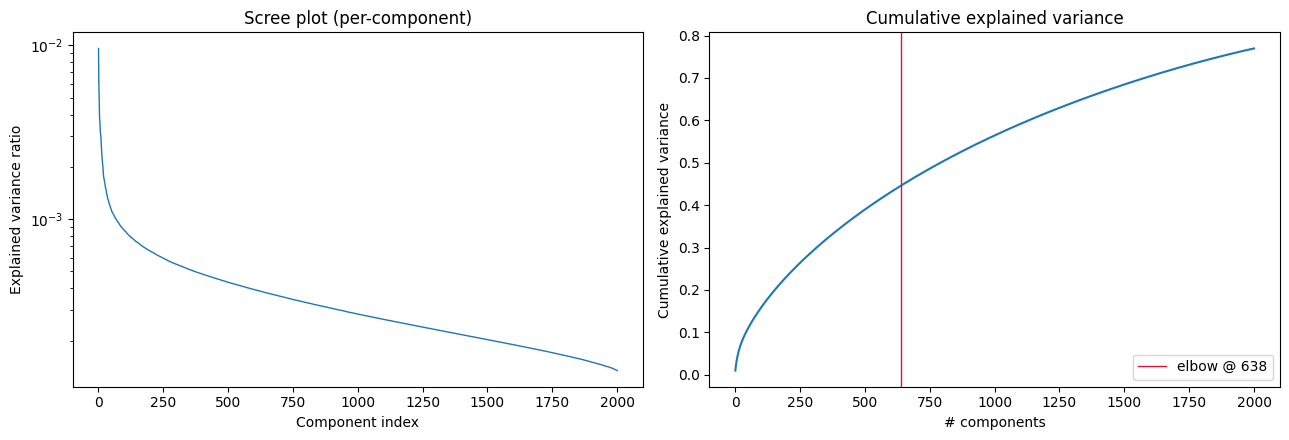

In [9]:
# Fit PCA with as many components as the data allows, capped for memory/speed.
# Full theoretical max is min(n_samples, n_features) = min(20000, 5000) = 5000;
# capped at 2000 so the curve still covers Task 2's largest fixed count.
max_components = min(X.shape[0], X.shape[1])
n_components_to_fit = min(max_components, 2000)

print(f"Fitting PCA with {n_components_to_fit} components on {X.shape}...")
pca = PCA(n_components=n_components_to_fit, svd_solver="randomized", random_state=42)
pca.fit(X)

evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)
print(f"Done. Cumulative variance at the last component: {cum_evr[-1]:.4f}")

# Pick component counts at canonical variance thresholds.
thresholds = [0.80, 0.90, 0.95, 0.99]
threshold_components = {
    t: int(np.searchsorted(cum_evr, t) + 1) if cum_evr[-1] >= t else None
    for t in thresholds
}
for t, n in threshold_components.items():
    if n is None:
        print(f"{t:.0%} variance: not reached within {n_components_to_fit} components")
    else:
        print(f"{t:.0%} variance: {n} components")

# Knee/elbow heuristic: maximum perpendicular distance from the line
# connecting the first and last points of the cumulative-variance curve.
x = np.arange(len(cum_evr))
y_curve = cum_evr
p1, p2 = np.array([x[0], y_curve[0]]), np.array([x[-1], y_curve[-1]])
line_vec = p2 - p1
line_vec_norm = line_vec / np.linalg.norm(line_vec)
points = np.column_stack([x, y_curve]) - p1
scalar_proj = points @ line_vec_norm
proj_points = np.outer(scalar_proj, line_vec_norm)
perp_distances = np.linalg.norm(points - proj_points, axis=1)
elbow_idx = int(np.argmax(perp_distances))
elbow_n_components = elbow_idx + 1
print(f"\nElbow estimate: {elbow_n_components} components "
      f"(captures {cum_evr[elbow_idx]:.2%} of variance)")

# Cross-reference against Task 2's fixed component counts (100/500/1000/2000).
for n in (100, 500, 1000, 2000):
    if n <= len(cum_evr):
        print(f"Task 2 count {n}: cumulative explained variance = {cum_evr[n - 1]:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: per-component explained variance (the literal scree)
axes[0].plot(np.arange(1, len(evr) + 1), evr, linewidth=1)
axes[0].set_xlabel("Component index")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (per-component)")
axes[0].set_yscale("log")

# Right: cumulative, with thresholds and elbow
axes[1].plot(np.arange(1, len(cum_evr) + 1), cum_evr, linewidth=1.5)
for t in thresholds:
    n = threshold_components[t]
    if n is not None:
        axes[1].axhline(t, linestyle="--", linewidth=0.7, color="gray")
        axes[1].axvline(n, linestyle=":", linewidth=0.7, color="gray")
        axes[1].text(n, t, f" {t:.0%} @ {n}", fontsize=8, va="bottom")
axes[1].axvline(elbow_n_components, color="crimson", linestyle="-", linewidth=1,
                label=f"elbow @ {elbow_n_components}")
axes[1].set_xlabel("# components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES / "scree_plot.png", dpi=120)
plt.show()

**Decision point: PCA components for downstream modeling (Task 3 exploration).**

Task 2 fixes its own components at 2000/1000/500/100, so this decision only applies to
Task 3's own exploratory models. Pick a small set to evaluate, not just one; comparing a
few is cheap and informative.

- The elbow estimate (above)
- The 90% and 95% variance points
- Optionally, no PCA at all; for tree-based models, dimension reduction often hurts more
  than it helps

Carry these numbers into `04_models.ipynb`.

## 7. Build & save the locked split

Built once, saved as index arrays; later notebooks load these rather than re-splitting.
Stratified: section 2 confirmed the class balance is skewed, so this is required, not
optional.

In [10]:
idx = np.arange(len(y))
dev_idx, holdout_idx = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=42
)

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
np.save(paths.DATA_PROCESSED / "dev_idx.npy", dev_idx)
np.save(paths.DATA_PROCESSED / "holdout_idx.npy", holdout_idx)

print(f"dev_idx: {len(dev_idx)} rows | holdout_idx: {len(holdout_idx)} rows")
print("dev class balance:    ", pd.Series(y[dev_idx]).value_counts(normalize=True).round(4).to_dict())
print("holdout class balance:", pd.Series(y[holdout_idx]).value_counts(normalize=True).round(4).to_dict())

assert len(set(dev_idx.tolist()) & set(holdout_idx.tolist())) == 0, "splits must be disjoint"
assert len(dev_idx) + len(holdout_idx) == len(idx), "splits must cover every row"
print("\nSaved to data/processed/dev_idx.npy and holdout_idx.npy - disjoint, full coverage confirmed.")

dev_idx: 16000 rows | holdout_idx: 4000 rows
dev class balance:     {1: 0.6252, 0: 0.3748}
holdout class balance: {1: 0.6252, 0: 0.3748}

Saved to data/processed/dev_idx.npy and holdout_idx.npy - disjoint, full coverage confirmed.


## Discussion / carry-forward -> `02_logreg_from_scratch.ipynb`

- **Schema confirmed:** 20,000 train rows; features are `'0001'` through `'5000'`
  (zero-padded strings); `id` is a non-numeric string column, always load with `dtype=str`.
- **Class balance is skewed (62.5% machine / 37.5% human):** stratification is
  **required** for every split and CV fold. A majority-class predictor scores ~63%
  accuracy but only ~0.385 Macro F1, so trust Macro F1, not accuracy.
- **Text length** (char/word count) differs somewhat between classes but is *not* a clean
  separator on its own; see `text_length_distribution.png`. Worth trying as a documented
  extra Task 3 feature if described in the report, not a primary signal.
- **Feature matrix is highly sparse** (see `feature_sparsity.png`), and a handful of
  features carry most of the class-separating signal (see `tfidf_feature_inspection.png`),
  useful for later error analysis, though the anonymized vocabulary limits interpretation
  to feature indices, not words.
- **Scree plot** shows the variance retained at 100/500/1000/2000 components, which
  builds intuition for Task 2's results, though Task 2 does not choose the count from
  this elbow.
- **Locked split saved:** `data/processed/dev_idx.npy` (~16,000 rows) and
  `holdout_idx.npy` (~4,000 rows), stratified, `random_state=42`. Every later notebook
  loads these; never re-split.
- **Next:** `02_logreg_from_scratch.ipynb` implements Task 1's from-scratch Logistic
  Regression (`sigmoid`, `loss`, `gradients`, `train`, `predict`) on `X[dev_idx]`,
  evaluated on `X[holdout_idx]`.